# Session 14 — Growing a dense model into a Mixture-of-Experts

**Assignment:** train a dense ("linear") model, convert it into a mixture-of-experts (MoE)
model, and show that the MoE keeps training and its loss keeps falling. Model size and data
are our choice. The repo must contain the training logs.

## The plan in one paragraph

A ~17M-parameter GPT is trained densely for 50M tokens of TinyStories. At that checkpoint its
feed-forward block (hidden width 1,536) is rebuilt, layer by layer, as **one shared expert of
width 768 plus 16 routed experts of width 192, of which each token uses 4**, the recipe the
instructor drew in class (lesson §15, Lightning LM). Each token still passes through 768 + 4 ×
192 = 1,536 hidden units, so the work per token is unchanged, while the feed-forward block now
stores about 2.5× as many weights. The routed experts are built by **drop-upcycling**
(Nakamura et al., arXiv 2502.19261): each expert takes a random 192 of the dense neurons the
shared expert did not take, and re-draws half of them from the statistics of the original
weights. The MoE then trains for another 50M tokens, **alongside a control that simply keeps
training the dense model on the same 50M tokens**, and a third run that differs from the MoE
only in routing (hard top-k from the first step instead of probabilistic top-k early on).

## What this notebook checks before believing anything

A loss curve that goes down proves little on its own: a broken router still lets the shared
expert and attention learn. Four gates run before any long run, as assertions that fail the
build:

1. **Copy upcycling reproduces the dense layer exactly.** Every expert a full copy of the dense
   FFN and router weights that sum to one: the MoE must compute the dense function to float64
   rounding, whatever the router picks. This exercises the dispatch/combine code.
2. **Shared + partitioned experts reproduce it exactly** when every expert is selected with
   equal weight and the routed scaling factor k is applied. This checks the neuron bookkeeping
   of the conversion, including the shared expert.
3. **The bias balancing rule balances.** On a deliberately skewed router, the lesson's sign rule
   must drive the maximum load violation down.
4. **The parameter count is what the design says**: active feed-forward parameters per token
   equal the dense block's (to within the router), and the total is about 2.5× the dense one.

After the dense phase, the same copy construction is applied to the *trained* checkpoint and
its validation loss must equal the dense model's.

## Contents

0. Environment
1. Data — TinyStories, the S13 tokenizer, 100M training tokens
2. The dense model
3. The mixture-of-experts layer
4. Converting a dense FFN into experts
5. Gates
6. The training loop and logs
7. Phase A — dense, 50M tokens
8. The conversion, measured on the trained model
9. Phase B — MoE, +50M tokens
10. Control — dense, +50M tokens
11. Ablation — MoE with hard top-k from the start
12. Results
13. Write results

## 0. Environment

In [1]:
import os, sys, json, math, time, pathlib, urllib.request, copy
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")
import numpy as np
import torch, torch.nn as nn, torch.nn.functional as F

T_START = time.perf_counter()
SMOKE = os.environ.get("S14_SMOKE") == "1"   # tiny everything, for a CPU dry run of the pipeline
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
AMP = DEVICE == "cuda"                       # fp16 autocast + GradScaler on GPU
ENV = {"device": DEVICE, "torch": torch.__version__, "smoke": SMOKE, "python": sys.version.split()[0]}
if DEVICE == "cuda":
    p = torch.cuda.get_device_properties(0)
    ENV |= {"gpu": p.name, "gpu_mem_gib": round(p.total_memory / 2**30, 2), "sm": f"{p.major}{p.minor}"}
    torch.backends.cuda.matmul.allow_tf32 = True
print(json.dumps(ENV, indent=2))

RESULTS = {"env": ENV}
for d_ in ("assets", "data", "logs"):
    pathlib.Path(d_).mkdir(exist_ok=True)

def autocast():
    return torch.autocast("cuda", dtype=torch.float16, enabled=AMP)

{
  "device": "cuda",
  "torch": "2.5.1+cu121",
  "smoke": false,
  "python": "3.10.12",
  "gpu": "Tesla T4",
  "gpu_mem_gib": 14.56,
  "sm": "75"
}


## 1. Data — TinyStories, the S13 tokenizer, 100M training tokens

Same data and tokenizer as Session 13: the GPT-4-generated TinyStories V2 split and an
8,192-token byte-level BPE trained on its first ~20MB (`assets/tokenizer.json`, carried over
unchanged). Two phases of 50M tokens need about 100M training tokens, so a ~480MB prefix of
the training file is fetched this time.

**Fixed data order.** The token stream is cut into windows of 512 tokens, shuffled once with a
fixed seed. The dense phase consumes the first 50M tokens of that order. Every run of the
second phase starts from the same point and consumes the *next* 50M tokens in the same order,
so the MoE, the control and the ablation see identical batches.

In [2]:
BASE = "https://huggingface.co/datasets/roneneldan/TinyStories/resolve/main/"
TRAIN_BYTES = 3_000_000 if SMOKE else 480_000_000
VALID_BYTES = 1_000_000 if SMOKE else 22_502_601
VOCAB = 8192
EOT = "<|endoftext|>"

def fetch(name, nbytes, dest):
    dest = pathlib.Path(dest)
    if dest.exists() and dest.stat().st_size >= nbytes - 1:
        return dest.read_bytes()
    req = urllib.request.Request(BASE + name, headers={"Range": f"bytes=0-{nbytes - 1}"})
    t = time.time()
    with urllib.request.urlopen(req) as r:
        raw = r.read()
    dest.write_bytes(raw)
    print(f"fetched {len(raw)/1e6:.1f} MB of {name} in {time.time()-t:.0f}s")
    return raw

def stories(raw):
    text = raw.decode("utf-8", errors="ignore")
    text = text[: text.rfind(EOT)]            # drop the partial story at the cut
    return [s.strip() for s in text.split(EOT) if s.strip()]

train_docs = stories(fetch("TinyStoriesV2-GPT4-train.txt", TRAIN_BYTES, "data/train_prefix.txt"))
valid_docs = stories(fetch("TinyStoriesV2-GPT4-valid.txt", VALID_BYTES, "data/valid.txt"))
print(f"{len(train_docs):,} training stories, {len(valid_docs):,} validation stories")

fetched 480.0 MB of TinyStoriesV2-GPT4-train.txt in 12s


fetched 22.5 MB of TinyStoriesV2-GPT4-valid.txt in 2s
585,700 training stories, 27,629 validation stories


In [3]:
from tokenizers import Tokenizer, models, trainers, pre_tokenizers, decoders

TOK_PATH = pathlib.Path("assets/tokenizer.json")
if TOK_PATH.exists():
    tok = Tokenizer.from_file(str(TOK_PATH))
else:                                          # same recipe as S13, if the file is missing
    tok = Tokenizer(models.BPE())
    tok.pre_tokenizer = pre_tokenizers.ByteLevel(add_prefix_space=False)
    tok.decoder = decoders.ByteLevel()
    trainer = trainers.BpeTrainer(vocab_size=VOCAB, special_tokens=[EOT],
                                  initial_alphabet=pre_tokenizers.ByteLevel.alphabet())
    n = 0; sample = []
    for d in train_docs:
        sample.append(d); n += len(d)
        if n > 20_000_000: break
    tok.train_from_iterator(sample, trainer)
    tok.save(str(TOK_PATH))
EOT_ID = tok.token_to_id(EOT)
assert tok.get_vocab_size() == VOCAB, tok.get_vocab_size()

In [4]:
SEQ = 64 if SMOKE else 512
BATCH = 8 if SMOKE else 64
PHASE_TOKENS = 100_000 if SMOKE else 50_000_000
STEPS_PHASE = math.ceil(PHASE_TOKENS / (BATCH * SEQ))

def encode_to(docs, limit, path):
    path = pathlib.Path(path)
    if path.exists():
        arr = np.fromfile(path, dtype=np.uint16)
        if len(arr) >= limit: return arr
    out, n = [], 0
    for i in range(0, len(docs), 20_000):
        for e in tok.encode_batch(docs[i:i + 20_000]):
            ids = e.ids + [EOT_ID]; out.append(np.asarray(ids, dtype=np.uint16)); n += len(ids)
        if n >= limit: break
    arr = np.concatenate(out)
    arr.tofile(path)
    return arr

t = time.time()
NEED = 2 * STEPS_PHASE * BATCH * SEQ + SEQ
train_ids = encode_to(train_docs, NEED + 1_000_000, "data/train.u16")
valid_ids = encode_to(valid_docs, 10**9, "data/valid.u16")
del train_docs, valid_docs
print(f"encoded in {time.time()-t:.0f}s: {len(train_ids)/1e6:.2f}M train tokens, "
      f"{len(valid_ids)/1e6:.2f}M validation tokens; two phases need {NEED/1e6:.2f}M")
assert len(train_ids) >= NEED, "not enough training text fetched for two phases"

N_WIN = (len(train_ids) - 1) // SEQ
WIN_ORDER = np.random.default_rng(1337).permutation(N_WIN)
train_t = torch.from_numpy(train_ids.astype(np.int64))
valid_t = torch.from_numpy(valid_ids.astype(np.int64))

def get_batch(global_step):
    """global_step counts from the start of the dense phase; phase B continues the count."""
    w = WIN_ORDER[global_step * BATCH:(global_step + 1) * BATCH]
    idx = torch.from_numpy(w * SEQ)[:, None] + torch.arange(SEQ + 1)[None, :]
    chunk = train_t[idx]
    return chunk[:, :-1].to(DEVICE, non_blocking=True), chunk[:, 1:].to(DEVICE, non_blocking=True)

EVAL_SEQS = 64 if SMOKE else 1024          # 1024 × 512 = 524K held-out tokens per evaluation
def valid_batches(bs=32):
    for i in range(0, EVAL_SEQS, bs):
        idx = torch.arange(i, i + bs)[:, None] * SEQ + torch.arange(SEQ + 1)[None, :]
        chunk = valid_t[idx]
        yield chunk[:, :-1].to(DEVICE), chunk[:, 1:].to(DEVICE)

RESULTS["data"] = {"dataset": "TinyStoriesV2-GPT4", "vocab": VOCAB, "seq_len": SEQ, "batch": BATCH,
                   "phase_tokens": STEPS_PHASE * BATCH * SEQ, "steps_per_phase": STEPS_PHASE,
                   "train_tokens_available": int(len(train_ids)), "valid_tokens": int(len(valid_ids)),
                   "eval_tokens": EVAL_SEQS * SEQ}

encoded in 59s: 102.62M train tokens, 5.42M validation tokens; two phases need 100.01M


## 2. The dense model

The Session 13 decoder with its ordinary residual rule: learned positions, pre-LayerNorm
blocks, a 4× GELU MLP, tied input and output embeddings, `scaled_dot_product_attention`.
Shape: width 384, 8 layers, 6 heads of 64, context 512. Session 13 went deep and narrow
(24 × 256) because reversibility saves memory in proportion to depth. A mixture-of-experts
model changes the feed-forward block, so this time the model is shallower and wider, which
gives the feed-forward block more of the parameters.

Dropout is zero. AdamW with weight decay 0.1 on matrices (the router is excluded, see §3).

In [5]:
CFG = dict(vocab=VOCAB, d=64 if SMOKE else 384, L=2 if SMOKE else 8, heads=2 if SMOKE else 6, T=SEQ)
H_DENSE = 4 * CFG["d"]

class Attn(nn.Module):
    def __init__(s, d, h):
        super().__init__(); s.h = h
        s.qkv = nn.Linear(d, 3 * d); s.o = nn.Linear(d, d)
    def forward(s, x):
        B, T, D = x.shape
        q, k, v = s.qkv(x).view(B, T, 3, s.h, D // s.h).permute(2, 0, 3, 1, 4)
        y = F.scaled_dot_product_attention(q, k, v, is_causal=True)
        return s.o(y.transpose(1, 2).reshape(B, T, D))

class Block(nn.Module):
    def __init__(s, d, h):
        super().__init__()
        s.ln1, s.ln2 = nn.LayerNorm(d), nn.LayerNorm(d)
        s.attn = Attn(d, h)
        s.mlp = nn.Sequential(nn.Linear(d, 4 * d), nn.GELU(), nn.Linear(4 * d, d))
    def forward(s, x):
        x = x + s.attn(s.ln1(x)).float()
        return x + s.mlp(s.ln2(x)).float()

class GPT(nn.Module):
    def __init__(s, vocab, d, L, heads, T):
        super().__init__()
        s.wte, s.wpe = nn.Embedding(vocab, d), nn.Embedding(T, d)
        s.blocks = nn.ModuleList(Block(d, heads) for _ in range(L))
        s.lnf = nn.LayerNorm(d)
        s.head = nn.Linear(d, vocab, bias=False)
        s.head.weight = s.wte.weight                           # tied
        s.apply(s._init)
        for n, prm in s.named_parameters():                    # GPT-2 scaled init on residual outputs
            if n.endswith("attn.o.weight") or n.endswith("mlp.2.weight"):
                nn.init.normal_(prm, 0.0, 0.02 / math.sqrt(2 * L))

    @staticmethod
    def _init(m):
        if isinstance(m, (nn.Linear, nn.Embedding)): nn.init.normal_(m.weight, 0.0, 0.02)
        if isinstance(m, nn.Linear) and m.bias is not None: nn.init.zeros_(m.bias)

    def forward(s, idx, targets=None):
        x = s.wte(idx) + s.wpe(torch.arange(idx.shape[1], device=idx.device))
        with autocast():
            for b in s.blocks: x = b(x)
            logits = s.head(s.lnf(x))
        if targets is None: return logits, None
        return logits, F.cross_entropy(logits.float().view(-1, logits.size(-1)), targets.reshape(-1))

def n_params(m):
    return sum(p.numel() for p in m.parameters())

_m = GPT(**CFG)
N_DENSE = n_params(_m)
FFN_DENSE = sum(p.numel() for p in _m.blocks[0].mlp.parameters())
print(f"dense model: {N_DENSE/1e6:.2f}M parameters, of which {CFG['L']} × {FFN_DENSE/1e6:.3f}M "
      f"= {CFG['L']*FFN_DENSE/1e6:.2f}M in the feed-forward blocks")
del _m

dense model: 17.54M parameters, of which 8 × 1.182M = 9.45M in the feed-forward blocks


## 3. The mixture-of-experts layer

Following lesson §3 and §7, for one token x (the LayerNorm output, width d):

1. **Router.** `probs = softmax(x · W_r)` over the 16 routed experts, computed in **float32**
   whatever the autocast setting (§7: Switch Transformer diverged with a 16-bit router), from a
   router initialised at one tenth of the usual scale (§7, Switch).
2. **Selection.** The k experts with the highest `probs + bias` (§13's auxiliary-loss-free
   balancing: the bias only chooses, it never weights). For the first steps after conversion
   the k experts are instead **sampled without replacement** in proportion to `probs + bias`
   (Gumbel top-k), the lesson's fix for experts that start out too alike (§15).
3. **Weights.** The chosen experts' *original* probabilities, renormalised to sum to one, times
   the **routed scaling factor k** (§7). Without the factor each of the k slices would be
   weighted about 1/k and the routed part of the block would start at a quarter of its dense
   size; with it, the routed sum is an unbiased estimate of the dense neurons it replaced
   (§4 below). Drop-upcycling's own appendix C.6 flags the same shrinkage for fine-grained
   experts.
4. **Output.** `y = shared(x) + Σ g_i · E_i(x) + b`, where every expert (shared and routed) is a
   GELU MLP without an output bias and b is the dense block's output bias, kept once.

**Dropless** (§11): tokens are sorted by expert and each expert runs on exactly the tokens sent
to it, however many that is.

**Balancing** (§13): after every optimiser step each layer's bias moves by
`γ · sign(1/E − load_i)` with γ = 0.001, where load_i is expert i's share of the step's
assignments. The count covers the whole batch (§14: whole-batch balancing, not per sequence).
There is **no auxiliary loss**.

In [6]:
GAMMA = 0.001

def route(probs, bias, k, sample):
    """Pick k experts per token. probs: (N, E) float32. Returns indices (N, k)."""
    score = probs + bias
    if sample:
        gumbel = -torch.log(-torch.log(torch.rand_like(score).clamp_(1e-20, 1.0)))
        return torch.topk(torch.log(score.clamp(min=1e-9)) + gumbel, k, dim=-1).indices
    return torch.topk(score, k, dim=-1).indices

def update_bias(bias, counts, k):
    """Lesson §13: b_i ← b_i + γ · sign(mean load − load_i)."""
    load = counts.float() / counts.sum().clamp(min=1)
    bias += GAMMA * torch.sign(1.0 / len(counts) - load)

class MoEFFN(nn.Module):
    def __init__(s, d, E, w, k, shared, scale, router_std=0.002):
        super().__init__()
        s.E, s.w, s.k, s.S, s.scale = E, w, k, shared, scale
        s.w1 = nn.Parameter(torch.zeros(E, d, w)); s.b1 = nn.Parameter(torch.zeros(E, w))
        s.w2 = nn.Parameter(torch.zeros(E, w, d))
        if shared:
            s.s1 = nn.Linear(d, shared); s.s2 = nn.Linear(shared, d, bias=False)
        s.out_bias = nn.Parameter(torch.zeros(d))
        s.router = nn.Parameter(torch.randn(d, E) * router_std)
        s.register_buffer("bias", torch.zeros(E))
        s.sample = False                       # probabilistic top-k, training only
        s.last_counts = None

    def forward(s, x):
        B, T, D = x.shape
        xf = x.reshape(-1, D)
        rd = torch.float64 if xf.dtype == torch.float64 else torch.float32
        with torch.autocast("cuda", enabled=False):
            probs = torch.softmax(xf.to(rd) @ s.router.to(rd), dim=-1)
        idx = route(probs, s.bias.to(rd), s.k, s.sample and s.training)
        g = probs.gather(1, idx)
        g = g / g.sum(-1, keepdim=True) * s.scale
        counts = torch.bincount(idx.reshape(-1), minlength=s.E)
        s.last_counts = counts.detach()

        out = s.out_bias.to(rd).expand(xf.shape[0], D).clone()
        if s.S:
            out += s.s2(F.gelu(s.s1(xf))).to(rd)
        flat_e = idx.reshape(-1)
        order = torch.argsort(flat_e, stable=True)
        tok = torch.arange(xf.shape[0], device=x.device).repeat_interleave(s.k)[order]
        gw = g.reshape(-1)[order]
        start = 0
        for e, n in enumerate(counts.tolist()):
            if n:
                t_e = tok[start:start + n]
                h = F.gelu(xf[t_e] @ s.w1[e] + s.b1[e]) @ s.w2[e]
                out.index_add_(0, t_e, h.to(rd) * gw[start:start + n, None])
            start += n
        return out.view(B, T, D)

def moe_layers(model):
    return [b.mlp for b in model.blocks if isinstance(b.mlp, MoEFFN)]

def set_sampling(model, on):
    for m in moe_layers(model): m.sample = on

## 4. Converting a dense FFN into experts

The dense block is `W2 · GELU(W1 x + b1) + b2`, with hidden width H = 1,536. Each hidden unit
("neuron") n is one row of W1, one entry of b1 and one column of W2, and the block's output is
the sum of the neurons' contributions plus b2. So any set of neurons, taken with their rows
and columns, is itself a smaller MLP, and a partition of the neurons into MLPs sums back to
the dense block exactly.

The conversion (`dense_to_moe`):

- **Shared expert:** the first S = H/2 = 768 neurons, unchanged. Every token uses it.
- **Routed experts**, built from the other P = 768 neurons (the "pool"), by one of three
  methods:
  - `copy`: every expert is the *whole* dense block (no shared expert). Sparse upcycling
    (Komatsuzaki et al., arXiv 2212.05055). Used here only as Gate 1.
  - `partition`: the pool cut into E disjoint slices. Used here only as Gate 2.
  - `sample`: each expert takes w = 192 neurons drawn at random from the pool, independently
    per expert, so experts overlap. With k = 4 experts per token and the scaling factor k, each
    pool neuron is expected to be used k·w/P = 4 × 192 / 768 = **1** time per token: an
    unbiased estimate of the dense block at conversion. This is the partition step of the
    Lightning LM recipe (§15) applied to the non-shared half.
- **Drop-upcycling** on top (`r`): in each routed expert a fraction r of its neurons is
  re-drawn. For the selected neurons, W1 rows, b1 entries and W2 columns are replaced by
  samples from a normal distribution with the mean and standard deviation of the original
  values at those neurons (arXiv 2502.19261, §3.2 eq. 4, and appendix C.6.1 for fine-grained
  experts). The paper's best ratio, r = 0.5, is used.
- **Router:** new, initialised small; **balancing bias:** zero.

The re-drawn half means the MoE is *not* the dense function at conversion. The loss jumps
there and has to recover; §8 measures by how much.

In [7]:
MOE = dict(E=16, k=4, S=H_DENSE // 2)
MOE["w"] = (H_DENSE - MOE["S"]) // MOE["k"]            # 192: k experts cover the pool once
R_DROP = 0.5
PROB_STEPS = 20 if SMOKE else 200                        # probabilistic top-k window after conversion

@torch.no_grad()
def dense_to_moe(mlp, method, E, w, k, S, scale, r=0.0, gen=None, router_std=0.002):
    W1, b1 = mlp[0].weight, mlp[0].bias                  # (H, d), (H,)
    W2, b2 = mlp[2].weight, mlp[2].bias                  # (d, H), (d,)
    H, d = W1.shape
    moe = MoEFFN(d, E, w, k, S, scale, router_std).to(W1.device, W1.dtype)
    moe.router.data = (torch.randn(d, E, generator=gen) * router_std).to(W1.device, W1.dtype)
    moe.out_bias.copy_(b2)
    if S:
        moe.s1.weight.copy_(W1[:S]); moe.s1.bias.copy_(b1[:S]); moe.s2.weight.copy_(W2[:, :S])
    pool = torch.arange(S, H)
    for e in range(E):
        if method == "copy":
            assert S == 0 and w == H
            n_e = torch.arange(H)
        elif method == "partition":
            assert E * w == len(pool)
            n_e = pool[e * w:(e + 1) * w]
        elif method == "sample":
            n_e = pool[torch.randperm(len(pool), generator=gen)[:w]]
        else:
            raise ValueError(method)
        u, bu, v = W1[n_e].clone(), b1[n_e].clone(), W2[:, n_e].clone()   # (w,d), (w,), (d,w)
        m = int(r * w)
        if m:
            sel = torch.randperm(w, generator=gen)[:m]
            def redraw(t):
                return (torch.randn(t.shape, generator=gen) * t.std() + t.mean()).to(t)
            u[sel] = redraw(u[sel]); bu[sel] = redraw(bu[sel]); v[:, sel] = redraw(v[:, sel])
        moe.w1[e].copy_(u.T); moe.b1[e].copy_(bu); moe.w2[e].copy_(v.T)
    return moe

def convert(dense_model, method="sample", r=R_DROP, seed=2024, **over):
    """A deep copy of dense_model with every block's MLP replaced by an MoE layer."""
    cfg = {**MOE, **over}
    gen = torch.Generator().manual_seed(seed)
    m = copy.deepcopy(dense_model).cpu()
    for b in m.blocks:
        b.mlp = dense_to_moe(b.mlp, method, cfg["E"], cfg["w"], cfg["k"], cfg["S"],
                             cfg.get("scale", cfg["k"]), r, gen)
    return m

def param_split(model):
    """Total parameters, and the parameters one token actually uses."""
    total = n_params(model)
    active = total
    for m in moe_layers(model):
        per_expert = m.w1[0].numel() + m.b1[0].numel() + m.w2[0].numel()
        active -= (m.E - m.k) * per_expert
    return total, active

## 5. Gates

In [8]:
def gate_equivalence():
    torch.manual_seed(0)
    d, H = 32, 128
    mlp = nn.Sequential(nn.Linear(d, H), nn.GELU(), nn.Linear(H, d)).double()
    for prm in mlp.parameters(): nn.init.normal_(prm, 0, 0.3)
    x = torch.randn(4, 16, d, dtype=torch.float64)
    ref = mlp(x)
    gen = torch.Generator().manual_seed(1)
    # Gate 1: copy upcycling, 4 full copies, top-2, a router large enough to route unevenly
    cp = dense_to_moe(mlp, "copy", E=4, w=H, k=2, S=0, scale=1.0, gen=gen, router_std=1.0)
    e1 = (cp(x) - ref).abs().max().item()
    used = int((cp.last_counts > 0).sum())
    # Gate 2: shared half + the pool partitioned into 4, all selected, uniform router, scale k
    pt = dense_to_moe(mlp, "partition", E=4, w=(H // 2) // 4, k=4, S=H // 2, scale=4.0, gen=gen)
    pt.router.data.zero_()
    e2 = (pt(x) - ref).abs().max().item()
    return e1, used, e2

E1, USED1, E2 = gate_equivalence()
print(f"Gate 1  copy upcycling vs dense:            max |Δ| = {E1:.1e}  ({USED1} of 4 experts used)")
print(f"Gate 2  shared + partition vs dense:        max |Δ| = {E2:.1e}")
assert E1 < 1e-12 and USED1 >= 2, "copy upcycling must reproduce the dense layer"
assert E2 < 1e-12, "shared + partitioned experts must reproduce the dense layer"

Gate 1  copy upcycling vs dense:            max |Δ| = 1.8e-15  (4 of 4 experts used)
Gate 2  shared + partition vs dense:        max |Δ| = 1.1e-14


In [9]:
def gate_balancing(E=16, k=4, N=4096, steps=400, seed=0):
    g = torch.Generator().manual_seed(seed)
    skew = torch.linspace(0, 3, E)                        # expert 15 is favoured by e^3 ≈ 20×
    bias = torch.zeros(E); vio = []
    for t in range(steps):
        probs = torch.softmax(torch.randn(N, E, generator=g) + skew, -1)
        counts = torch.bincount(route(probs, bias, k, False).reshape(-1), minlength=E)
        load = counts.float() / counts.sum()
        vio.append(((load.max() - 1 / E) * E).item())
        update_bias(bias, counts, k)
    return vio

VIO = gate_balancing()
print(f"Gate 3  bias balancing on a skewed router:  MaxVio {VIO[0]:.2f} at step 0 → "
      f"{np.mean(VIO[-50:]):.2f} averaged over the last 50 of {len(VIO)} steps")
assert np.mean(VIO[-50:]) < 0.25 * VIO[0], "the sign rule must balance a skewed router"

Gate 3  bias balancing on a skewed router:  MaxVio 1.90 at step 0 → 0.09 averaged over the last 50 of 400 steps


In [10]:
_dense = GPT(**CFG)
_moe = convert(_dense)
TOT_MOE, ACT_MOE = param_split(_moe)
m0 = _moe.blocks[0].mlp
FFN_MOE_TOTAL = n_params(m0)
FFN_MOE_ACTIVE = FFN_MOE_TOTAL - (m0.E - m0.k) * (m0.w1[0].numel() + m0.b1[0].numel() + m0.w2[0].numel())
print(f"Gate 4  per-layer FFN parameters: dense {FFN_DENSE:,}; MoE total {FFN_MOE_TOTAL:,} "
      f"({FFN_MOE_TOTAL/FFN_DENSE:.2f}×), active {FFN_MOE_ACTIVE:,} "
      f"(dense + {FFN_MOE_ACTIVE-FFN_DENSE:,}: the router's d×E)")
print(f"        whole model: dense {N_DENSE/1e6:.2f}M; MoE {TOT_MOE/1e6:.2f}M total, "
      f"{ACT_MOE/1e6:.2f}M active per token")
assert FFN_MOE_ACTIVE - FFN_DENSE == CFG["d"] * MOE["E"], "active FFN = dense FFN + router"
assert SMOKE or 2.3 < FFN_MOE_TOTAL / FFN_DENSE < 2.7
del _dense, _moe, m0

RESULTS["gates"] = {"copy_max_err": E1, "partition_max_err": E2, "maxvio_start": VIO[0],
                    "maxvio_end": float(np.mean(VIO[-50:]))}
RESULTS["model"] = {**CFG, "ffn_hidden": H_DENSE, "dense_params": N_DENSE, "dense_params_M": N_DENSE / 1e6,
                    "ffn_dense_per_layer": FFN_DENSE, "ffn_moe_total_per_layer": FFN_MOE_TOTAL,
                    "ffn_moe_active_per_layer": FFN_MOE_ACTIVE, "ffn_ratio": FFN_MOE_TOTAL / FFN_DENSE,
                    "moe_params_M": TOT_MOE / 1e6, "moe_active_M": ACT_MOE / 1e6,
                    "E": MOE["E"], "k": MOE["k"], "expert_width": MOE["w"], "shared_width": MOE["S"],
                    "r_drop": R_DROP, "gamma": GAMMA, "prob_steps": PROB_STEPS}

Gate 4  per-layer FFN parameters: dense 1,181,568; MoE total 2,959,488 (2.50×), active 1,187,712 (dense + 6,144: the router's d×E)
        whole model: dense 17.54M; MoE 31.76M total, 17.59M active per token


## 6. The training loop and logs

- AdamW, β = (0.9, 0.95), weight decay 0.1 on matrices and expert weights (not on biases,
  LayerNorms or the router), gradient clipping at 1.0, float16 autocast with a GradScaler.
- **Warmup-stable-decay schedule.** The dense phase warms up over its first 3% of steps and
  then holds the peak LR of 1e-3, so the checkpoint handed to phase B has not been annealed.
  Each phase-B run gets a **fresh optimiser** (the MoE has new parameters and no optimiser
  state for them; the control is treated the same way), warms up again over 2% of its steps,
  holds the peak, and decays linearly to 10% over its last 20%. The MoE and the control run on
  the identical schedule.
- Validation loss on 1,024 held-out sequences (524K tokens), with **hard top-k routing**: at
  every evaluation, densely just after the switch and then at ten even points.
- **Logs.** Every step appends one JSON line to `logs/train_<run>.jsonl`: step, tokens, loss,
  LR, gradient norm, and for MoE runs the per-layer maximum load violation (MaxVio) and the
  number of experts that received no token that step. Every evaluation appends a line with the
  validation loss and, for MoE runs, each layer's full load vector over the validation set.

In [11]:
LR = 1e-3
HOURLY_USD = 0.828     # g4dn.2xlarge on-demand, ap-south-1 (Mumbai), Linux; AWS Pricing API 2026-09-25

def lr_dense(step, total):
    warm = max(1, int(0.03 * total))
    return LR * min(1.0, (step + 1) / warm)

def lr_cont(step, total):
    warm, decay_from = max(1, int(0.02 * total)), int(0.8 * total)
    if step < warm: return LR * (step + 1) / warm
    if step < decay_from: return LR
    return LR * (1 - 0.9 * (step - decay_from) / max(1, total - decay_from))

def make_opt(model):
    decay, no_decay = [], []
    for n, prm in model.named_parameters():
        (no_decay if prm.dim() < 2 or n.endswith("router") else decay).append(prm)
    return torch.optim.AdamW([{"params": decay, "weight_decay": 0.1},
                              {"params": no_decay, "weight_decay": 0.0}],
                             lr=LR, betas=(0.9, 0.95), fused=DEVICE == "cuda")

@torch.no_grad()
def evaluate(model, with_load=False):
    model.eval(); tot, n = 0.0, 0
    loads = [torch.zeros(m.E, device=DEVICE) for m in moe_layers(model)] if with_load else None
    for x, y in valid_batches():
        tot += model(x, y)[1].item(); n += 1
        if with_load:
            for l, m in zip(loads, moe_layers(model)): l += m.last_counts
    model.train()
    if with_load:
        return tot / n, [(l / l.sum()).tolist() for l in loads]
    return tot / n, None

def load_stats(model):
    vio, dead = [], []
    for m in moe_layers(model):
        c = m.last_counts.float()
        load = c / c.sum()
        vio.append(round(((load.max() - 1 / m.E) * m.E).item(), 4)); dead.append(int((c == 0).sum()))
    return vio, dead

def train(name, model, steps, step0, lr_fn, sample_steps=0, eval_extra=()):
    """step0: global index of this phase's first batch in the fixed data order."""
    model = model.to(DEVICE)
    opt = make_opt(model)
    scaler = torch.amp.GradScaler("cuda", enabled=AMP)
    is_moe = bool(moe_layers(model))
    evals_at = set(np.linspace(0, steps, 11).astype(int).tolist()[1:]) | {s for s in eval_extra if s < steps}
    if DEVICE == "cuda":
        torch.cuda.empty_cache(); torch.cuda.reset_peak_memory_stats()
    log_path = pathlib.Path(f"logs/train_{name}.jsonl"); log_path.write_text("")
    fh = log_path.open("a")
    curve = {"step": [], "loss": []}
    evals = {"step": [], "tokens": [], "val_loss": [], "load": []}
    run_time, timed_tokens, t_wall, pending = 0.0, 0, time.perf_counter(), []

    def do_eval(step_done):
        v, loads = evaluate(model, with_load=is_moe)
        evals["step"].append(step_done); evals["tokens"].append(step_done * BATCH * SEQ)
        evals["val_loss"].append(v); evals["load"].append(loads)
        rec = {"eval": True, "step": step_done, "tokens": step_done * BATCH * SEQ, "val_loss": round(v, 5)}
        if is_moe:
            rec["val_load"] = [[round(a, 5) for a in l] for l in loads]
            rec["val_dead"] = [sum(1 for a in l if a == 0) for l in loads]
        fh.write(json.dumps(rec) + "\n"); fh.flush()
        msg = (f"  {name:12s} step {step_done:5d}/{steps}  val {v:.4f}"
               + (f"  train {curve['loss'][-1]:.4f}" if curve["loss"] else "")
               + (f"  dead(val) {sum(rec['val_dead'])}" if is_moe else ""))
        print(msg, flush=True)
        with open("logs/progress.txt", "a") as pf:
            pf.write(time.strftime("%H:%M:%S ") + msg + "\n")

    def flush():
        for s_, l_, g_, lr_, st_ in pending:
            rec = {"step": s_ + 1, "tokens": (s_ + 1) * BATCH * SEQ, "loss": round(l_.item(), 5),
                   "lr": lr_, "grad_norm": round(g_.item(), 4)}
            if st_:
                rec["maxvio"], rec["dead"] = st_
                rec["sampled_topk"] = s_ < sample_steps
            fh.write(json.dumps(rec) + "\n")
            curve["step"].append(s_ + 1); curve["loss"].append(rec["loss"])
        fh.flush(); pending.clear()

    do_eval(0)                                           # the model exactly as handed over
    for step in range(steps):
        set_sampling(model, step < sample_steps)
        lr = lr_fn(step, steps)
        for g_ in opt.param_groups: g_["lr"] = lr
        x, y = get_batch(step0 + step)
        if DEVICE == "cuda": torch.cuda.synchronize()
        t0 = time.perf_counter()
        loss = model(x, y)[1]
        scaler.scale(loss).backward()
        scaler.unscale_(opt)
        gn = torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(opt); scaler.update(); opt.zero_grad(set_to_none=True)
        stats = load_stats(model) if is_moe else None
        for m in moe_layers(model):
            update_bias(m.bias, m.last_counts, m.k)
        if DEVICE == "cuda": torch.cuda.synchronize()
        if step >= 20:
            run_time += time.perf_counter() - t0; timed_tokens += BATCH * SEQ
        pending.append((step, loss.detach(), gn.detach(), lr, stats))
        if step % 25 == 0 or step == steps - 1:
            flush()
            assert math.isfinite(curve["loss"][-1]), f"{name}: loss is not finite at step {step}"
        if step + 1 in evals_at:
            flush()                                      # so the printed train loss is current
            do_eval(step + 1)
    fh.close()
    wall = time.perf_counter() - t_wall
    res = {"name": name, "steps": steps, "tokens_trained": steps * BATCH * SEQ,
           "val_start": evals["val_loss"][0], "final_val_loss": evals["val_loss"][-1],
           "final_train_loss": float(np.mean(curve["loss"][-max(1, len(curve["loss"]) // 20):])),
           "tokens_per_s": timed_tokens / run_time if run_time else float("nan"),
           "wall_min": wall / 60, "cost_usd": wall / 3600 * HOURLY_USD,
           "params_total": param_split(model)[0], "params_active": param_split(model)[1]}
    if DEVICE == "cuda":
        res["peak_alloc_gib"] = torch.cuda.max_memory_allocated() / 2**30
    print(f"  → {name}: val {res['val_start']:.4f} → {res['final_val_loss']:.4f}, "
          f"{res['tokens_per_s']/1e3:.1f}K tok/s, {res['wall_min']:.1f} min")
    model.cpu()
    if DEVICE == "cuda": torch.cuda.empty_cache()
    return res, curve, evals

RUNS, CURVES, EVALS = {}, {}, {}

## 7. Phase A — dense, 50M tokens

In [12]:
torch.manual_seed(1234)
dense = GPT(**CFG)
RUNS["dense"], CURVES["dense"], EVALS["dense"] = train("dense", dense, STEPS_PHASE, 0, lr_dense)
DENSE_CKPT = copy.deepcopy(dense.state_dict())
DENSE_VAL = RUNS["dense"]["final_val_loss"]

  dense        step     0/1526  val 9.1058


  dense        step   152/1526  val 3.2984  train 3.2739


  dense        step   305/1526  val 2.5999  train 2.6121


  dense        step   457/1526  val 2.2813  train 2.3192


  dense        step   610/1526  val 2.1075  train 2.0641


...

  dense        step  1068/1526  val 1.8326  train 1.7932


  dense        step  1220/1526  val 1.7868  train 1.7656


  dense        step  1373/1526  val 1.7482  train 1.7367


  dense        step  1526/1526  val 1.7119  train 1.7349


  → dense: val 9.1058 → 1.7119, 97.3K tok/s, 8.9 min


## 8. The conversion, measured on the trained model

Four versions of the trained checkpoint, each evaluated on the same validation tokens with
hard top-k:

- the dense model itself;
- **copy** upcycling (2 full copies, top-2, weights summing to one): must equal the dense loss,
  which checks the conversion on the real weights rather than a toy;
- **sample, r = 0** (shared half + 16 sampled experts, nothing re-drawn): how much is lost by
  routing each token through only 4 of the 16 slices;
- **sample, r = 0.5**, the model phase B starts from: the extra cost of re-drawing half of every
  routed expert.

In [13]:
def val_of(model):
    model.to(DEVICE); v = evaluate(model)[0]; model.cpu(); return v

dense.load_state_dict(DENSE_CKPT)
CONV = {"dense": DENSE_VAL}
CONV["copy"] = val_of(convert(dense, "copy", r=0.0, E=2, k=2, S=0, w=H_DENSE, scale=1.0))
CONV["sample_r0"] = val_of(convert(dense, "sample", r=0.0))
CONV["sample_r05"] = val_of(convert(dense, "sample", r=R_DROP))
for k_, v_ in CONV.items():
    print(f"  {k_:11s} val loss {v_:.4f}   (Δ vs dense {v_ - DENSE_VAL:+.4f})")
assert abs(CONV["copy"] - DENSE_VAL) < 2e-3, "copy upcycling must keep the trained model's loss"
RESULTS["conversion"] = {**CONV, "jump_r0": CONV["sample_r0"] - DENSE_VAL,
                         "jump_r05": CONV["sample_r05"] - DENSE_VAL,
                         "copy_delta": CONV["copy"] - DENSE_VAL}

  dense       val loss 1.7119   (Δ vs dense +0.0000)
  copy        val loss 1.7119   (Δ vs dense +0.0000)
  sample_r0   val loss 1.8553   (Δ vs dense +0.1434)
  sample_r05  val loss 2.2278   (Δ vs dense +0.5160)


## 9. Phase B — MoE, +50M tokens

The drop-upcycled model (r = 0.5), probabilistic top-k for its first 200 steps, then hard top-k.
Extra evaluations early on show how quickly it recovers from the conversion.

In [14]:
EARLY = (10, 25, 50, 100, 150, 200, 300, 450) if not SMOKE else (5, 10)
torch.manual_seed(99)
moe = convert(dense, "sample", r=R_DROP)
RUNS["moe"], CURVES["moe"], EVALS["moe"] = train("moe", moe, STEPS_PHASE, STEPS_PHASE, lr_cont,
                                                 sample_steps=PROB_STEPS, eval_extra=EARLY)
MOE_BIAS = [m.bias.cpu().tolist() for m in moe_layers(moe)]
del moe

  moe          step     0/1526  val 2.2278  dead(val) 0


  moe          step    10/1526  val 1.9070  train 1.9502  dead(val) 0


  moe          step    25/1526  val 1.8283  train 1.7708  dead(val) 0


  moe          step    50/1526  val 1.7951  train 1.7625  dead(val) 0


  moe          step   100/1526  val 1.7612  train 1.7943  dead(val) 0


...

  moe          step  1068/1526  val 1.5898  train 1.6127  dead(val) 0


  moe          step  1220/1526  val 1.5752  train 1.5384  dead(val) 0


  moe          step  1373/1526  val 1.5114  train 1.4715  dead(val) 0


  moe          step  1526/1526  val 1.4523  train 1.5270  dead(val) 0


  → moe: val 2.2278 → 1.4523, 45.5K tok/s, 19.6 min


## 10. Control — dense, +50M tokens

The same checkpoint, not converted, on the same batches with the same schedule and a fresh
optimiser. Anything the MoE gains over this run comes from the conversion, not from training
longer.

In [15]:
torch.manual_seed(99)
dense.load_state_dict(DENSE_CKPT)
cont = copy.deepcopy(dense)
RUNS["dense_cont"], CURVES["dense_cont"], EVALS["dense_cont"] = train(
    "dense_cont", cont, STEPS_PHASE, STEPS_PHASE, lr_cont, eval_extra=EARLY)
del cont

  dense_cont   step     0/1526  val 1.7119


  dense_cont   step    10/1526  val 1.6680  train 1.6877


  dense_cont   step    25/1526  val 1.6866  train 1.6218


  dense_cont   step    50/1526  val 1.7058  train 1.6652


  dense_cont   step   100/1526  val 1.6942  train 1.7287


...

  dense_cont   step  1068/1526  val 1.5734  train 1.5995


  dense_cont   step  1220/1526  val 1.5642  train 1.5236


  dense_cont   step  1373/1526  val 1.5026  train 1.4601


  dense_cont   step  1526/1526  val 1.4445  train 1.5194


  → dense_cont: val 1.7119 → 1.4445, 97.0K tok/s, 9.2 min


## 11. Ablation — MoE with hard top-k from the start

Identical to §9, same conversion seed and so the same initial experts, except that routing is
hard top-k from the first step. Lesson §15 reports that near-identical clones under hard top-k
collapse onto a few members of each clone family. Our experts are **not** clones (each is a
different random draw of neurons, half of them re-drawn), and the router starts small and
random, so the prediction here is a **small** effect: the mechanism behind the lesson's failure
is mostly removed by the initialisation itself. The dead-expert counts in the logs test that.

In [16]:
torch.manual_seed(99)
moe_hard = convert(dense, "sample", r=R_DROP)
RUNS["moe_hard"], CURVES["moe_hard"], EVALS["moe_hard"] = train(
    "moe_hard", moe_hard, STEPS_PHASE, STEPS_PHASE, lr_cont, sample_steps=0, eval_extra=EARLY)
del moe_hard

  moe_hard     step     0/1526  val 2.2278  dead(val) 0


  moe_hard     step    10/1526  val 1.8780  train 1.9078  dead(val) 0


  moe_hard     step    25/1526  val 1.8105  train 1.7497  dead(val) 0


  moe_hard     step    50/1526  val 1.7825  train 1.7496  dead(val) 0


  moe_hard     step   100/1526  val 1.7486  train 1.7873  dead(val) 0


...

  moe_hard     step  1068/1526  val 1.5836  train 1.6037  dead(val) 0


  moe_hard     step  1220/1526  val 1.5685  train 1.5250  dead(val) 0


  moe_hard     step  1373/1526  val 1.5052  train 1.4628  dead(val) 0


  moe_hard     step  1526/1526  val 1.4437  train 1.5205  dead(val) 0


  → moe_hard: val 2.2278 → 1.4437, 45.6K tok/s, 19.5 min


## 12. Results

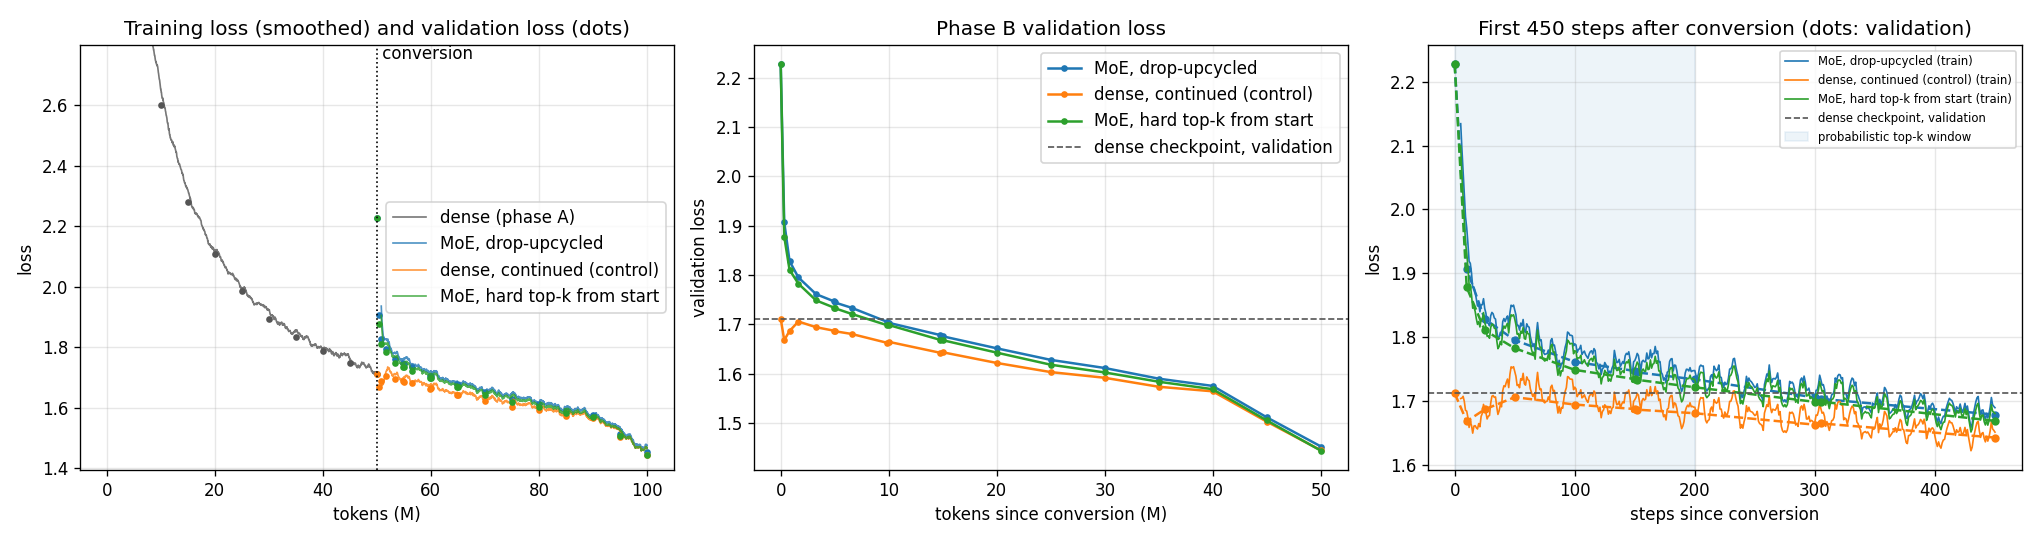

In [17]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import Image, display

TOK_A = STEPS_PHASE * BATCH * SEQ
def smooth(y, w=25):
    y = np.asarray(y, float); w = max(1, min(w, len(y)))
    return np.convolve(y, np.ones(w) / w, mode="valid")

COL = {"dense": "#555555", "moe": "#1f77b4", "dense_cont": "#ff7f0e", "moe_hard": "#2ca02c"}
LBL = {"dense": "dense (phase A)", "moe": "MoE, drop-upcycled", "dense_cont": "dense, continued (control)",
       "moe_hard": "MoE, hard top-k from start"}

fig, (a1, a2, a3) = plt.subplots(1, 3, figsize=(17, 4.5))
ZOOM = min(STEPS_PHASE, 20 if SMOKE else 450)             # steps after conversion shown in the zoom
for k_ in ("dense", "moe", "dense_cont", "moe_hard"):
    off = 0 if k_ == "dense" else TOK_A
    c = CURVES[k_]; s = smooth(c["loss"])
    a1.plot((np.asarray(c["step"][len(c["step"]) - len(s):]) * BATCH * SEQ + off) / 1e6, s,
            color=COL[k_], lw=1, alpha=.8, label=LBL[k_])
    e = EVALS[k_]
    a1.plot((np.asarray(e["tokens"]) + off) / 1e6, e["val_loss"], "o", color=COL[k_], ms=3)
    if k_ != "dense":
        a2.plot(np.asarray(e["tokens"]) / 1e6, e["val_loss"], "o-", color=COL[k_], ms=3, label=LBL[k_])
        z = smooth(c["loss"][:ZOOM], 5)
        a3.plot(c["step"][len(c["step"][:ZOOM]) - len(z):ZOOM], z, color=COL[k_], lw=1, label=LBL[k_] + " (train)")
        ez = [(st_, v_) for st_, v_ in zip(e["step"], e["val_loss"]) if st_ <= ZOOM]
        a3.plot(*zip(*ez), "o--", color=COL[k_], ms=4)
lo = min(min(min(v["val_loss"]) for v in EVALS.values()),
         min(smooth(c["loss"]).min() for c in CURVES.values())) - 0.05
hi = EVALS["dense"]["val_loss"][min(2, len(EVALS["dense"]["val_loss"]) - 1)] + 0.2
a1.set_ylim(lo, hi)
a1.axvline(TOK_A / 1e6, color="k", ls=":", lw=1); a1.text(TOK_A / 1e6, hi, " conversion", va="top")
a1.set_xlabel("tokens (M)"); a1.set_ylabel("loss"); a1.set_title("Training loss (smoothed) and validation loss (dots)")
a1.legend(); a1.grid(alpha=.3)
for ax_ in (a2, a3):
    ax_.axhline(DENSE_VAL, color="#555555", ls="--", lw=1, label="dense checkpoint, validation")
    ax_.grid(alpha=.3)
a2.set_xlabel("tokens since conversion (M)"); a2.set_ylabel("validation loss")
a2.set_title("Phase B validation loss"); a2.legend()
a3.axvspan(0, PROB_STEPS, color="#1f77b4", alpha=.08, label="probabilistic top-k window")
a3.set_xlabel("steps since conversion"); a3.set_ylabel("loss")
a3.set_title(f"First {ZOOM} steps after conversion (dots: validation)"); a3.legend(fontsize=7)
fig.tight_layout(); fig.savefig("assets/loss_curves.png", dpi=120); plt.close(fig)
display(Image("assets/loss_curves.png"))

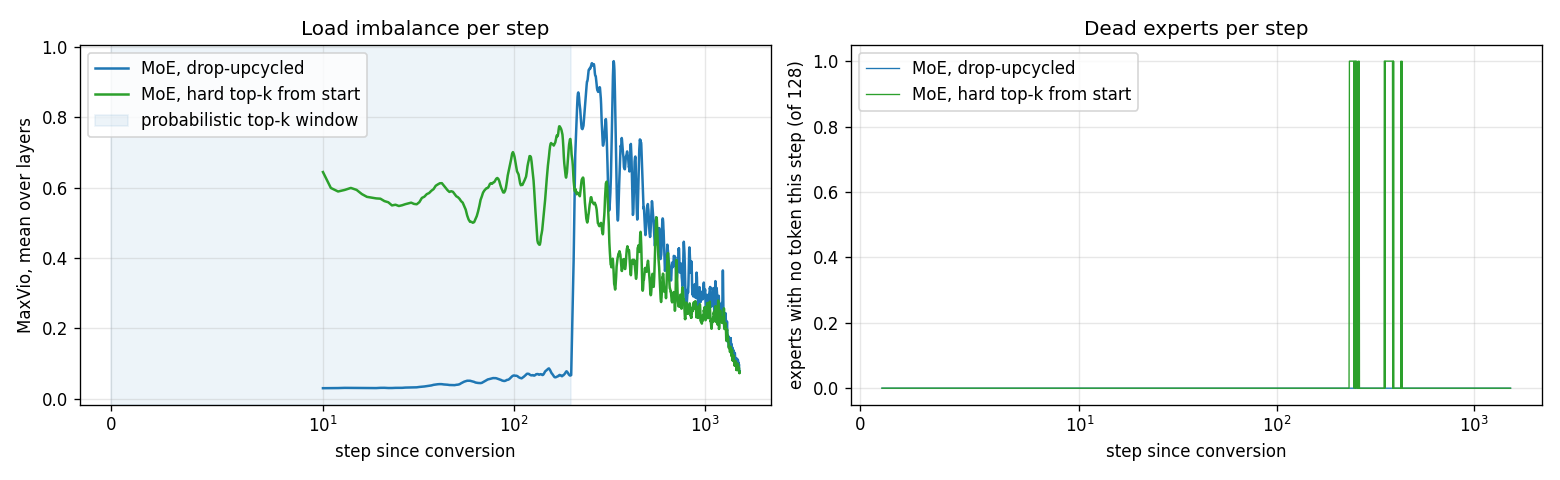

In [18]:
def per_step(name, key):
    rows = [json.loads(l) for l in open(f"logs/train_{name}.jsonl") if l.strip()]
    rows = [r for r in rows if not r.get("eval")]
    return np.array([r["step"] for r in rows]), np.array([r[key] for r in rows], float)

fig, (b1, b2) = plt.subplots(1, 2, figsize=(13, 4))
for k_ in ("moe", "moe_hard"):
    st, vio = per_step(k_, "maxvio"); _, dead = per_step(k_, "dead")
    sm = smooth(vio.mean(1), 10)
    b1.plot(st[len(st) - len(sm):], sm, color=COL[k_], label=LBL[k_])
    b2.plot(st, dead.sum(1), color=COL[k_], lw=.8, label=LBL[k_])
b1.axvspan(0, PROB_STEPS, color="#1f77b4", alpha=.08, label="probabilistic top-k window")
b1.set_xscale("symlog", linthresh=10); b1.set_xlabel("step since conversion")
b1.set_ylabel("MaxVio, mean over layers"); b1.set_title("Load imbalance per step"); b1.legend(); b1.grid(alpha=.3)
b2.set_xscale("symlog", linthresh=10); b2.set_xlabel("step since conversion")
b2.set_ylabel(f"experts with no token this step (of {CFG['L']*MOE['E']})"); b2.set_title("Dead experts per step")
b2.legend(); b2.grid(alpha=.3)
fig.tight_layout(); fig.savefig("assets/expert_load.png", dpi=120); plt.close(fig)
display(Image("assets/expert_load.png"))

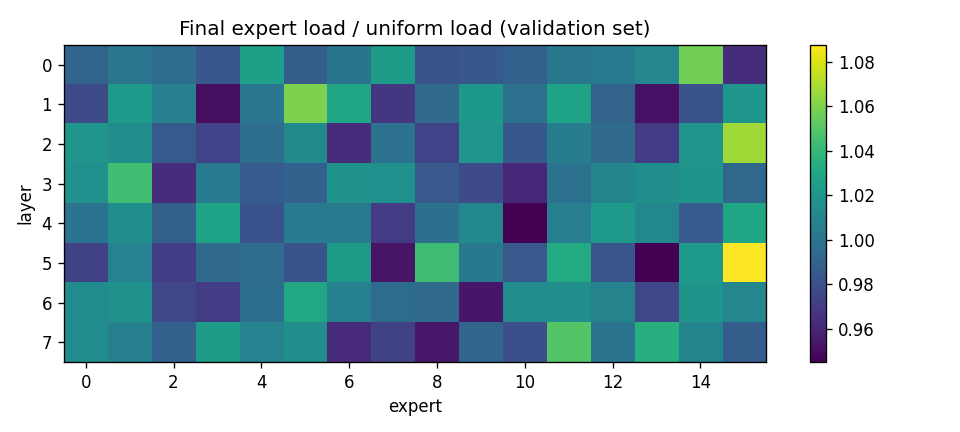

In [19]:
last_load = np.array(EVALS["moe"]["load"][-1])            # (L, E), shares over the validation set
fig, ax = plt.subplots(figsize=(8, 3.6))
im = ax.imshow(last_load * MOE["E"], aspect="auto", cmap="viridis")
ax.set_xlabel("expert"); ax.set_ylabel("layer"); ax.set_title("Final expert load / uniform load (validation set)")
fig.colorbar(im, ax=ax); fig.tight_layout(); fig.savefig("assets/final_load.png", dpi=120); plt.close(fig)
display(Image("assets/final_load.png"))

In [20]:
def recovery_tokens(name):
    """Tokens after conversion until validation loss first returns to the dense checkpoint's."""
    e = EVALS[name]
    for t_, v_ in zip(e["tokens"], e["val_loss"]):
        if v_ <= DENSE_VAL: return t_
    return None

base = RUNS["dense_cont"]["final_val_loss"]
SUMMARY = {}
for k_ in ("moe", "dense_cont", "moe_hard"):
    r_ = RUNS[k_]
    ld = np.array(EVALS[k_]["load"][-1]) if EVALS[k_]["load"][-1] else None
    SUMMARY[k_] = {"val_start": r_["val_start"], "val_end": r_["final_val_loss"],
                   "drop_in_phase_b": r_["val_start"] - r_["final_val_loss"],
                   "vs_dense_ckpt": r_["final_val_loss"] - DENSE_VAL,
                   "vs_control": r_["final_val_loss"] - base,
                   "recovery_tokens_M": (float("nan") if recovery_tokens(k_) is None else recovery_tokens(k_) / 1e6),
                   "final_val_maxvio": float(((ld.max(1) - 1 / MOE["E"]) * MOE["E"]).mean()) if ld is not None else None,
                   "final_val_dead": int((ld == 0).sum()) if ld is not None else None}
    print(f"{k_:11s} val {r_['val_start']:.4f} → {r_['final_val_loss']:.4f}  "
          f"(vs dense checkpoint {SUMMARY[k_]['vs_dense_ckpt']:+.4f}, vs control {SUMMARY[k_]['vs_control']:+.4f})  "
          f"{r_['tokens_per_s']/1e3:.1f}K tok/s")
_, dead_moe = per_step("moe", "dead"); _, dead_hard = per_step("moe_hard", "dead")
RESULTS["summary"] = SUMMARY
RESULTS["dead_per_step"] = {"moe_max": int(dead_moe.sum(1).max()), "moe_hard_max": int(dead_hard.sum(1).max()),
                            "moe_last100_mean": float(dead_moe.sum(1)[-100:].mean()),
                            "moe_hard_last100_mean": float(dead_hard.sum(1)[-100:].mean())}
print(json.dumps(RESULTS["dead_per_step"]))

moe         val 2.2278 → 1.4523  (vs dense checkpoint -0.2596, vs control +0.0078)  45.5K tok/s
dense_cont  val 1.7119 → 1.4445  (vs dense checkpoint -0.2674, vs control +0.0000)  97.0K tok/s
moe_hard    val 2.2278 → 1.4437  (vs dense checkpoint -0.2682, vs control -0.0008)  45.6K tok/s
{"moe_max": 0, "moe_hard_max": 1, "moe_last100_mean": 0.0, "moe_hard_last100_mean": 0.0}


## 13. Write results

In [21]:
RESULTS["runs"] = RUNS
RESULTS["curves"] = {k: {"tokens": v["tokens"], "val_loss": v["val_loss"]} for k, v in EVALS.items()}
RESULTS["moe_final_bias"] = MOE_BIAS
RESULTS["meta"] = {"hourly_usd": HOURLY_USD, "lr": LR,
                   "total_runtime_min": (time.perf_counter() - T_START) / 60,
                   "total_cost_usd": (time.perf_counter() - T_START) / 3600 * HOURLY_USD}
if not SMOKE:
    pathlib.Path("results.json").write_text(json.dumps(RESULTS, indent=2, default=float))
print("===RESULTS-JSON-BEGIN===")
print(json.dumps({k: v for k, v in RESULTS.items() if k != "curves"}, default=float))
print("===RESULTS-JSON-END===")
print(f"total notebook runtime {RESULTS['meta']['total_runtime_min']:.1f} min, "
      f"≈ ${RESULTS['meta']['total_cost_usd']:.2f} of GPU time")

===RESULTS-JSON-BEGIN===
{"env": {"device": "cuda", "torch": "2.5.1+cu121", "smoke": false, "python": "3.10.12", "gpu": "Tesla T4", "gpu_mem_gib": 14.56, "sm": "75"}, "data": {"dataset": "TinyStoriesV2-GPT4", "vocab": 8192, "seq_len": 512, "batch": 64, "phase_tokens": 50003968, "steps_per_phase": 1526, "train_tokens_available": 102615789, "valid_tokens": 5417537, "eval_tokens": 524288}, "gates": {"copy_max_err": 1.7763568394002505e-15, "partition_max_err": 1.0658141036401503e-14, "maxvio_start": 1.8974609375, "maxvio_end": 0.08900390625}, "model": {"vocab": 8192, "d": 384, "L": 8, "heads": 6, "T": 512, "ffn_hidden": 1536, "dense_params": 17538816, "dense_params_M": 17.538816, "ffn_dense_per_layer": 1181568, "ffn_moe_total_per_layer": 2959488, "ffn_moe_active_per_layer": 1187712, "ffn_ratio": 2.504712382190445, "moe_params_M": 31.762176, "moe_active_M": 17.587968, "E": 16, "k": 4, "expert_width": 192, "shared_width": 768, "r_drop": 0.5, "gamma": 0.001, "prob_steps": 200}, "conversion": 